# RQ-VAE training experiments

Four runs on the MovieLens 1M content embeddings:

1. **L=1, K=256** — plain VQ-VAE sanity check.
2. **L=3, K=256** — full RQ-VAE at SPEC defaults.
3. **L=3, K=128** — smaller codebooks (better-suited to ~3.9k movies).
4. **L=3, K=64**  — smallest codebooks.

Plots refresh after each run completes, so you can watch results accumulate.

**Prerequisite**: run `python -m src.data --download --config config.yaml` once before executing this notebook.

In [1]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.train import load_config, train

BASE_CFG = load_config("config.yaml")

histories: dict[str, list[dict]] = {}

## Plotting helper

Re-renders all four panels using whatever runs are present in `histories` at the time of the call.

In [2]:
def plot_progress(histories: dict[str, list[dict]]) -> None:
    if not histories:
        print("(no runs yet)")
        return
    n_runs = len(histories)

    # ---- recon loss across runs ----
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for label, hist in histories.items():
        epochs = [m["epoch"] for m in hist]
        ax.plot(epochs, [m["recon_loss"] for m in hist], label=label)
    ax.set_xlabel("epoch"); ax.set_ylabel("recon loss (eval pass)")
    ax.set_title("Reconstruction loss"); ax.legend(); ax.grid(alpha=0.3)
    plt.show()

    # # ---- utilization per level, one subplot per run ----
    # fig, axes = plt.subplots(1, n_runs, figsize=(4 * n_runs, 4), sharey=True, squeeze=False)
    # for ax, (label, hist) in zip(axes[0], histories.items()):
    #     util = np.array([m["utilization"] for m in hist])
    #     epochs = [m["epoch"] for m in hist]
    #     for l in range(util.shape[1]):
    #         ax.plot(epochs, util[:, l], label=f"level {l}")
    #     ax.set_title(label); ax.set_xlabel("epoch")
    #     ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # axes[0, 0].set_ylabel("utilization")
    # fig.suptitle("Codebook utilization per level"); fig.tight_layout()
    # plt.show()

    # # ---- perplexity per level, one subplot per run ----
    # fig, axes = plt.subplots(1, n_runs, figsize=(4 * n_runs, 4), squeeze=False)
    # for ax, (label, hist) in zip(axes[0], histories.items()):
    #     ppl = np.array([m["perplexity"] for m in hist])
    #     epochs = [m["epoch"] for m in hist]
    #     for l in range(ppl.shape[1]):
    #         ax.plot(epochs, ppl[:, l], label=f"level {l}")
    #     ax.set_title(label); ax.set_xlabel("epoch")
    #     ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # axes[0, 0].set_ylabel("perplexity")
    # fig.suptitle("Codebook perplexity per level"); fig.tight_layout()
    # plt.show()

    # # ---- final SID uniqueness across runs ----
    # labels = list(histories.keys())
    # uniq = [histories[l][-1]["sid_unique_fraction"] for l in labels]
    # coll = [histories[l][-1]["sid_collisions"] for l in labels]
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    # ax1.bar(labels, uniq, color="steelblue")
    # ax1.set_ylim(0, 1.05); ax1.set_ylabel("unique SID fraction")
    # ax1.set_title("SID uniqueness (higher = better)")
    # ax1.tick_params(axis="x", rotation=20)
    # for i, v in enumerate(uniq):
    #     ax1.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
    # ax2.bar(labels, coll, color="indianred")
    # ax2.set_ylabel("# colliding SIDs")
    # ax2.set_title("SID collisions (lower = better)")
    # ax2.tick_params(axis="x", rotation=20)
    # for i, v in enumerate(coll):
    #     ax2.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
    # fig.tight_layout()
    # plt.show()

## Run helper

Each call appends to `histories` and re-renders all plots immediately.

In [3]:
import time

def run_experiment(
    num_levels: int,
    codebook_size: int,
    reinit_enabled: bool = True,
    epochs: int = 300,
    lr: float = 1e-3,
) -> None:
    # Auto-label: always include L and K; append flags only when non-default.
    parts = [f"L={num_levels}", f"K={codebook_size}"]
    if not reinit_enabled:
        parts.append("no reinit")
    if lr != 1e-3:
        parts.append(f"lr={lr:.0e}")
    if epochs != 300:
        parts.append(f"epochs={epochs}")
    label = ", ".join(parts)

    cfg = copy.deepcopy(BASE_CFG)
    cfg["model"]["num_levels"] = num_levels
    cfg["model"]["codebook_size"] = codebook_size
    cfg["train"]["epochs"] = epochs
    cfg["train"]["lr"] = lr
    cfg["train"]["reinit_enabled"] = reinit_enabled

    slug = label.replace(" ", "").replace(",", "_").replace("=", "")
    out_root = Path("outputs") / f"exp_{slug}"
    cfg["output"]["checkpoints_dir"] = str(out_root / "checkpoints")
    cfg["output"]["metrics_json"] = str(out_root / "metrics.json")
    cfg["output"]["sids_csv"] = str(out_root / "sids.csv")

    print(
        f"\n========== {label}  "
        f"(epochs={epochs}, lr={lr:.0e}, out: {out_root}) =========="
    )
    t0 = time.perf_counter()
    histories[label] = train(cfg)
    elapsed = time.perf_counter() - t0
    mins, secs = divmod(elapsed, 60)
    print(f"[time] {label}: {int(mins)}m {secs:.1f}s  ({elapsed:.1f}s total)")
    # Plot ONLY this run's curves. Cross-run comparison happens at the
    # bottom of the notebook in its own cell.
    plot_progress({label: histories[label]})

## Run 1 — VQ-VAE sanity (L=1, K=256)

Only 256 possible SIDs for 3883 movies, so `sid_unique_fraction` will hit the pigeonhole floor (~0.066). Purpose of the run: confirm quantizer mechanics work in isolation.


========== L=1, K=256  (epochs=300, lr=1e-03, out: outputs/exp_L1_K256) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=1  K=256  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9934  recon=0.9906  rq=0.0028  util=['0.44']  ppl=['10.3']  uniq=0.029
[train] epoch   2/300  loss=0.9741  recon=0.9575  rq=0.0165  util=['0.31']  ppl=['11.0']  uniq=0.021
[train] epoch   3/300  loss=0.9418  recon=0.9269  rq=0.0150  util=['0.23']  ppl=['8.8']  uniq=0.015
[train] epoch   4/300  loss=0.9445  recon=0.9176  rq=0.0269  util=['0.21']  ppl=['9.1']  uniq=0.014
[train] epoch   5/300  loss=0.9292  recon=0.9026  rq=0.0266  util=['0.20']  ppl=['10.6']  uniq=0.013
[train] epoch   6/300  loss=0.9265  recon=0.8943  rq=0.0323  util=['0.16']  ppl=['11.4']  uniq=0.010
[train] epoch   7/300  loss=0.9188  recon=0.8865  rq=0.0323  util=['0.13']  ppl=['11.8']  uniq=0.008
[train] epoch   8/300  loss=0.9131  recon=0.8809  rq=0.0322  util=[

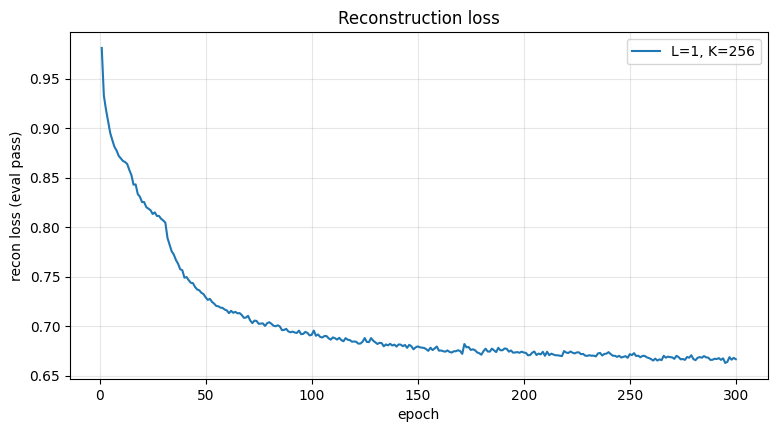

In [4]:
run_experiment(num_levels=1, codebook_size=256)

## Run 2 — RQ-VAE, L=3, K=256 (SPEC defaults)


========== L=3, K=256  (epochs=300, lr=1e-03, out: outputs/exp_L3_K256) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=256  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9920  recon=0.9898  rq=0.0022  util=['0.67', '0.85', '0.92']  ppl=['26.6', '58.1', '88.0']  uniq=0.613
[train] epoch   2/300  loss=0.9572  recon=0.9482  rq=0.0090  util=['0.25', '0.44', '0.62']  ppl=['13.1', '15.2', '20.6']  uniq=0.284
[train] epoch   3/300  loss=0.8964  recon=0.8830  rq=0.0134  util=['0.30', '0.62', '0.86']  ppl=['14.6', '29.3', '50.5']  uniq=0.478
[train] epoch   4/300  loss=0.8627  recon=0.8541  rq=0.0086  util=['0.35', '0.66', '0.86']  ppl=['17.8', '41.3', '76.9']  uniq=0.648
[train] epoch   5/300  loss=0.8525  recon=0.8436  rq=0.0089  util=['0.32', '0.55', '0.72']  ppl=['17.8', '38.8', '54.8']  uniq=0.607
[train] epoch   6/300  loss=0.8454  recon=0.8336  rq=0.0118  util=['0.27', '0.46', '0.59']  ppl=['17.6', '3

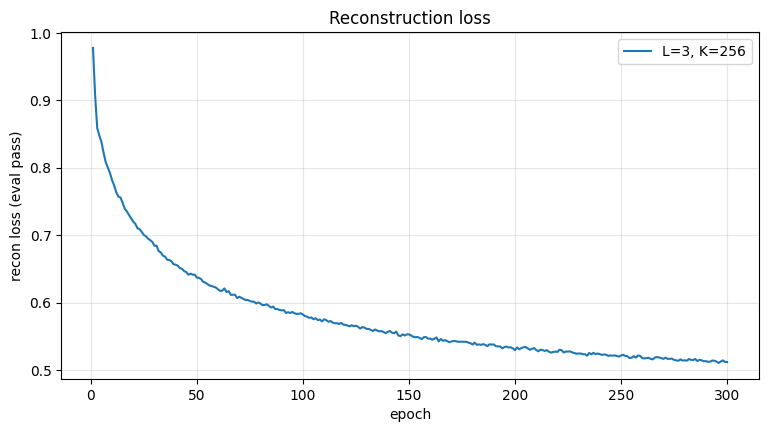

In [5]:
run_experiment(num_levels=3, codebook_size=256)


========== L=3, K=256, lr=5e-03  (epochs=300, lr=5e-03, out: outputs/exp_L3_K256_lr5e-03) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=256  D=32


[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9638  recon=0.9569  rq=0.0069  util=['0.39', '0.56', '0.78']  ppl=['14.9', '24.2', '40.4']  uniq=0.391
[train] epoch   2/300  loss=0.8873  recon=0.8769  rq=0.0104  util=['0.32', '0.45', '0.71']  ppl=['17.5', '26.6', '44.8']  uniq=0.465
[train] epoch   3/300  loss=0.8569  recon=0.8462  rq=0.0107  util=['0.29', '0.50', '0.74']  ppl=['18.3', '31.2', '54.3']  uniq=0.531
[train] epoch   4/300  loss=0.8352  recon=0.8257  rq=0.0095  util=['0.23', '0.38', '0.60']  ppl=['16.3', '25.3', '39.1']  uniq=0.490
[train] epoch   5/300  loss=0.8254  recon=0.8118  rq=0.0136  util=['0.21', '0.30', '0.46']  ppl=['16.5', '23.3', '31.5']  uniq=0.469
[train] epoch   6/300  loss=0.8136  recon=0.7969  rq=0.0167  util=['0.23', '0.32', '0.48']  ppl=['16.9', '22.8', '33.4']  uniq=0.498
[train] epoch   7/300  loss=0.8026  recon=0.7857  rq=0.0169  util=['0.18', '0.31', '0.49']  ppl=['16.2', '23.7', '39.0']  uniq=0.547
[train] epoch

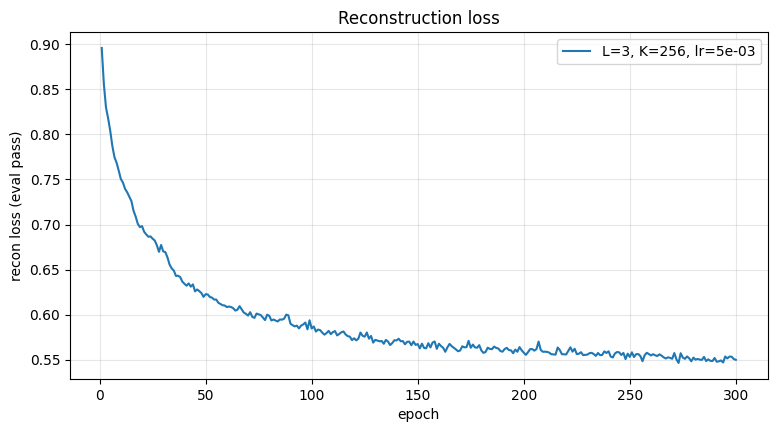

In [6]:
run_experiment(num_levels=3, codebook_size=256, lr=5e-3)


========== L=3, K=128  (epochs=300, lr=1e-03, out: outputs/exp_L3_K128) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=128  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9926  recon=0.9906  rq=0.0020  util=['0.88', '0.93', '0.98']  ppl=['22.7', '37.2', '57.0']  uniq=0.522
[train] epoch   2/300  loss=0.9690  recon=0.9573  rq=0.0117  util=['0.41', '0.61', '0.71']  ppl=['12.6', '14.8', '16.8']  uniq=0.249
[train] epoch   3/300  loss=0.9124  recon=0.8904  rq=0.0220  util=['0.45', '0.60', '0.84']  ppl=['11.7', '13.2', '24.2']  uniq=0.288
[train] epoch   4/300  loss=0.8739  recon=0.8587  rq=0.0152  util=['0.54', '0.72', '0.84']  ppl=['13.2', '19.8', '30.8']  uniq=0.397
[train] epoch   5/300  loss=0.8624  recon=0.8483  rq=0.0142  util=['0.49', '0.65', '0.77']  ppl=['13.2', '19.9', '29.8']  uniq=0.407
[train] epoch   6/300  loss=0.8560  recon=0.8393  rq=0.0167  util=['0.45', '0.63', '0.75']  ppl=['13.2', '1

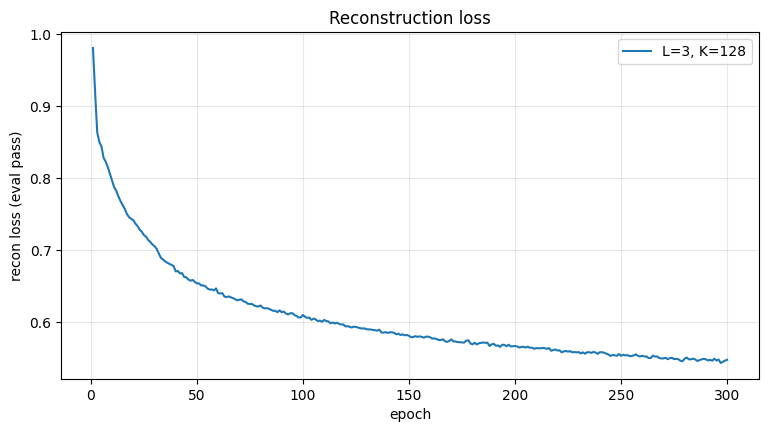

In [7]:
run_experiment(num_levels=3, codebook_size=128)

## Run 3 — RQ-VAE, L=3, K=128


========== L=3, K=64  (epochs=300, lr=1e-03, out: outputs/exp_L3_K64) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=64  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9929  recon=0.9911  rq=0.0019  util=['0.98', '1.00', '1.00']  ppl=['19.8', '26.4', '33.1']  uniq=0.457
[train] epoch   2/300  loss=0.9791  recon=0.9659  rq=0.0132  util=['0.67', '0.77', '0.91']  ppl=['10.8', '11.0', '14.8']  uniq=0.176
[train] epoch   3/300  loss=0.9399  recon=0.9130  rq=0.0269  util=['0.61', '0.77', '0.89']  ppl=['11.7', '10.1', '13.1']  uniq=0.215
[train] epoch   4/300  loss=0.8964  recon=0.8824  rq=0.0140  util=['0.73', '0.78', '0.94']  ppl=['13.0', '16.2', '20.5']  uniq=0.308
[train] epoch   5/300  loss=0.8891  recon=0.8706  rq=0.0185  util=['0.70', '0.69', '0.86']  ppl=['11.8', '11.7', '12.4']  uniq=0.212
[train] epoch   6/300  loss=0.8792  recon=0.8563  rq=0.0229  util=['0.73', '0.77', '0.84']  ppl=['12.2', '14.5

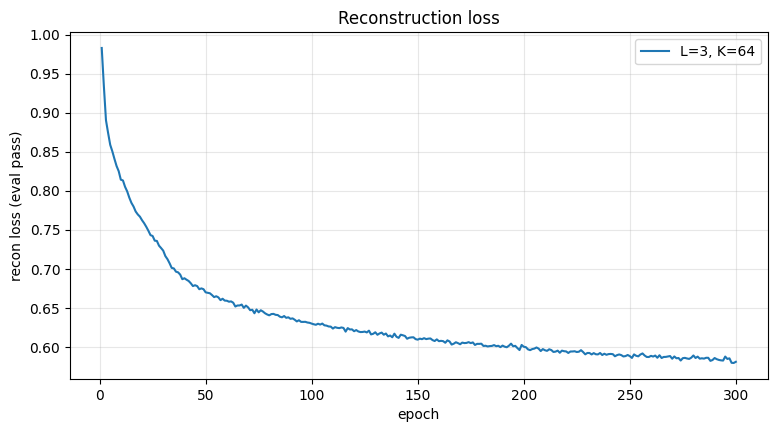

In [8]:
run_experiment(num_levels=3, codebook_size=64)


========== L=3, K=256, no reinit  (epochs=300, lr=1e-03, out: outputs/exp_L3_K256_noreinit) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=256  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9920  recon=0.9898  rq=0.0022  util=['0.67', '0.85', '0.92']  ppl=['26.6', '58.1', '88.0']  uniq=0.613
[train] epoch   2/300  loss=0.9572  recon=0.9482  rq=0.0090  util=['0.25', '0.44', '0.62']  ppl=['13.1', '15.2', '20.6']  uniq=0.284
[train] epoch   3/300  loss=0.8964  recon=0.8830  rq=0.0134  util=['0.30', '0.62', '0.86']  ppl=['14.6', '29.3', '50.5']  uniq=0.478
[train] epoch   4/300  loss=0.8627  recon=0.8541  rq=0.0086  util=['0.35', '0.66', '0.86']  ppl=['17.8', '41.3', '76.9']  uniq=0.648
[train] epoch   5/300  loss=0.8525  recon=0.8436  rq=0.0089  util=['0.32', '0.55', '0.72']  ppl=['17.8', '38.8', '54.8']  uniq=0.607
[train] epoch   6/300  loss=0.8454  recon=0.8336  rq=0.0118  util=['0.27', '0.46', '0.5

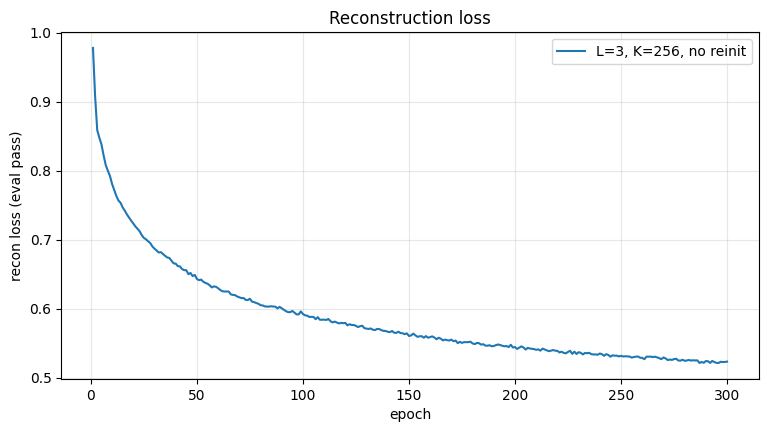

In [9]:
run_experiment(num_levels=3, codebook_size=256, reinit_enabled=False)


========== L=3, K=128, no reinit  (epochs=300, lr=1e-03, out: outputs/exp_L3_K128_noreinit) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=128  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/300  loss=0.9926  recon=0.9906  rq=0.0020  util=['0.89', '0.93', '0.98']  ppl=['22.7', '37.2', '56.9']  uniq=0.522
[train] epoch   2/300  loss=0.9690  recon=0.9573  rq=0.0117  util=['0.41', '0.61', '0.73']  ppl=['12.7', '14.8', '17.1']  uniq=0.249
[train] epoch   3/300  loss=0.9113  recon=0.8898  rq=0.0215  util=['0.40', '0.61', '0.85']  ppl=['11.9', '13.2', '25.7']  uniq=0.306
[train] epoch   4/300  loss=0.8727  recon=0.8577  rq=0.0149  util=['0.52', '0.66', '0.84']  ppl=['13.1', '19.7', '32.3']  uniq=0.405
[train] epoch   5/300  loss=0.8625  recon=0.8480  rq=0.0145  util=['0.51', '0.65', '0.80']  ppl=['13.0', '19.7', '29.2']  uniq=0.385
[train] epoch   6/300  loss=0.8567  recon=0.8396  rq=0.0171  util=['0.48', '0.60', '0.7

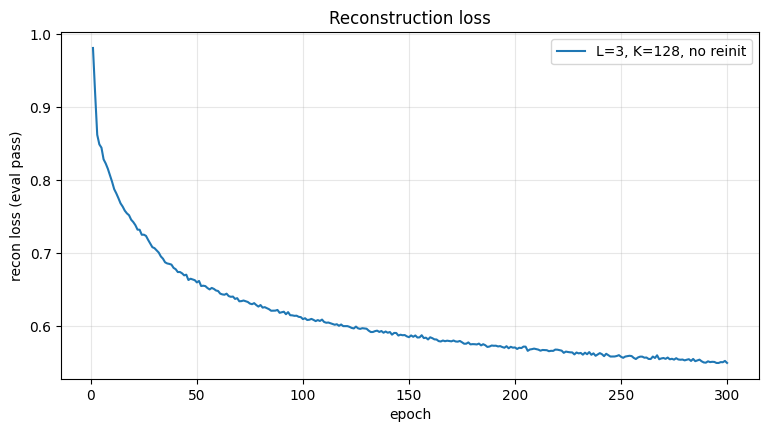

In [11]:
run_experiment(num_levels=3, codebook_size=128, reinit_enabled=False)



========== L=3, K=256, epochs=1000  (epochs=1000, lr=1e-03, out: outputs/exp_L3_K256_epochs1000) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=256  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/1000  loss=0.9920  recon=0.9898  rq=0.0022  util=['0.67', '0.85', '0.92']  ppl=['26.6', '58.1', '88.0']  uniq=0.613
[train] epoch   2/1000  loss=0.9572  recon=0.9482  rq=0.0090  util=['0.25', '0.44', '0.62']  ppl=['13.1', '15.2', '20.6']  uniq=0.284
[train] epoch   3/1000  loss=0.8964  recon=0.8830  rq=0.0134  util=['0.30', '0.62', '0.86']  ppl=['14.6', '29.3', '50.5']  uniq=0.478
[train] epoch   4/1000  loss=0.8627  recon=0.8541  rq=0.0086  util=['0.35', '0.66', '0.86']  ppl=['17.8', '41.3', '76.9']  uniq=0.648
[train] epoch   5/1000  loss=0.8525  recon=0.8436  rq=0.0089  util=['0.32', '0.55', '0.72']  ppl=['17.8', '38.8', '54.8']  uniq=0.607
[train] epoch   6/1000  loss=0.8454  recon=0.8336  rq=0.0118  util=['0.27', '

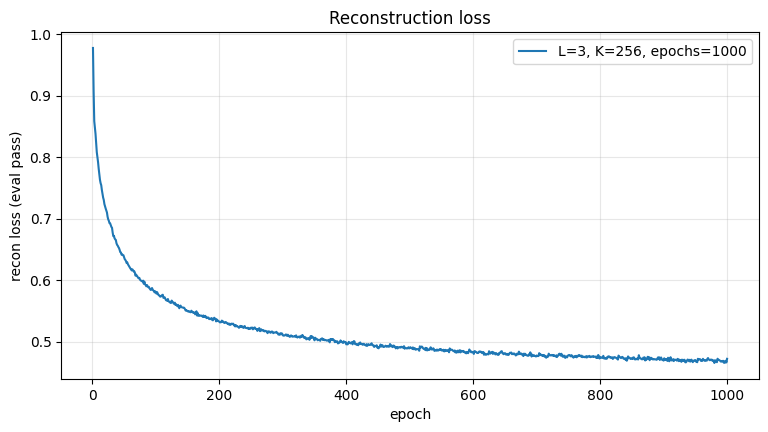

In [14]:
run_experiment(num_levels=3, codebook_size=256, epochs=1000)


========== L=3, K=128, epochs=1000  (epochs=1000, lr=1e-03, out: outputs/exp_L3_K128_epochs1000) ==========
[train] device=cpu
[train] loaded embeddings (3883, 384)
[train] model L=3  K=128  D=32
[train] k-means init done on full corpus (3883 latents)
[train] epoch   1/1000  loss=0.9926  recon=0.9906  rq=0.0020  util=['0.88', '0.93', '0.98']  ppl=['22.7', '37.2', '57.0']  uniq=0.522
[train] epoch   2/1000  loss=0.9690  recon=0.9573  rq=0.0117  util=['0.41', '0.61', '0.71']  ppl=['12.6', '14.8', '16.8']  uniq=0.249
[train] epoch   3/1000  loss=0.9124  recon=0.8904  rq=0.0220  util=['0.45', '0.60', '0.84']  ppl=['11.7', '13.2', '24.2']  uniq=0.288
[train] epoch   4/1000  loss=0.8739  recon=0.8587  rq=0.0152  util=['0.54', '0.72', '0.84']  ppl=['13.2', '19.8', '30.8']  uniq=0.397
[train] epoch   5/1000  loss=0.8624  recon=0.8483  rq=0.0142  util=['0.49', '0.65', '0.77']  ppl=['13.3', '19.9', '29.9']  uniq=0.410
[train] epoch   6/1000  loss=0.8561  recon=0.8394  rq=0.0167  util=['0.45', '

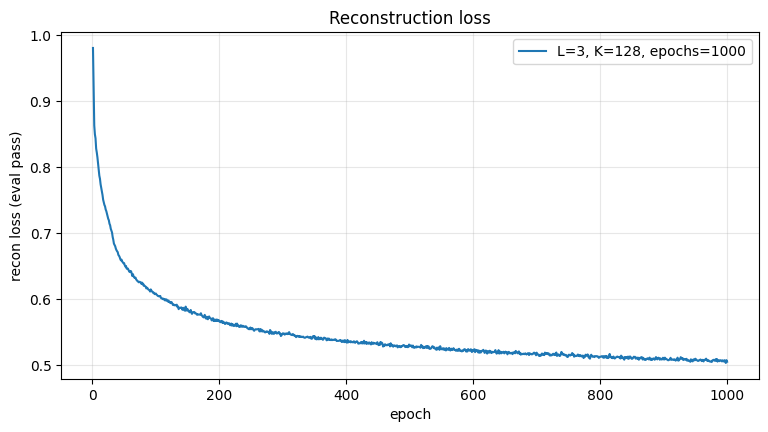

In [15]:
run_experiment(num_levels=3, codebook_size=128, epochs=1000)

## Compare across all runs

Re-renders every panel (recon, utilization, perplexity, SID uniqueness) using every run currently in `histories`.

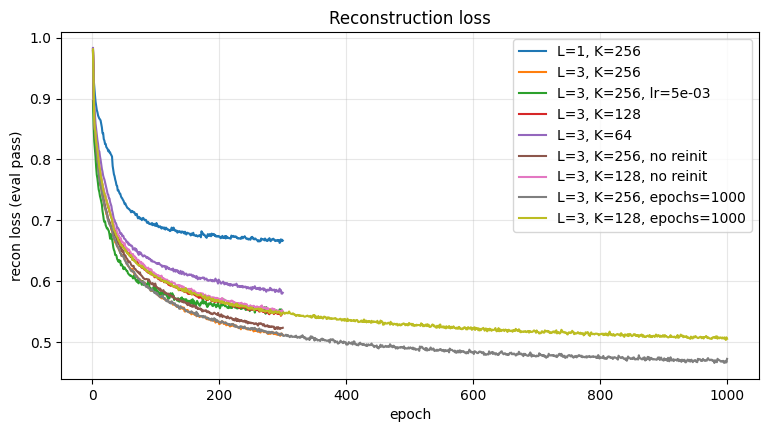

In [16]:
plot_progress(histories)

## Final-epoch metrics table

In [ ]:
import pandas as pd

rows = []
for label, hist in histories.items():
    m = hist[-1]
    rows.append({
        "run": label,
        "recon": round(m["recon_loss"], 4),
        "utilization": [round(u, 3) for u in m["utilization"]],
        "perplexity": [round(p, 1) for p in m["perplexity"]],
        "sid_unique": round(m["sid_unique_fraction"], 4),
        "sid_collisions": m["sid_collisions"],
    })
pd.DataFrame(rows)

,run,recon,utilization,perplexity,sid_unique,sid_collisions
0,"L=1, K=256",0.6667,[1.0],[235.3],0.0659,3627
1,"L=3, K=256",0.5117,"[0.996, 0.996, 1.0]","[227.4, 234.1, 235.0]",0.9990,4
2,"L=3, K=256, lr=5e-03",0.5500,"[1.0, 1.0, 0.988]","[238.8, 231.1, 231.2]",0.9979,8
3,"L=3, K=128",0.5477,"[1.0, 1.0, 1.0]","[117.3, 121.1, 122.5]",0.9943,22
4,"L=3, K=64",0.5810,"[1.0, 1.0, 1.0]","[60.4, 61.7, 61.9]",0.9719,109
5,"L=3, K=256, no reinit",0.5235,"[0.5, 1.0, 1.0]","[113.3, 241.7, 244.3]",0.9972,11
6,"L=3, K=128, no reinit",0.5498,"[0.875, 1.0, 1.0]","[100.8, 122.5, 123.8]",0.9933,26
7,"L=3, K=256, epochs=1000",0.4725,"[0.965, 0.953, 0.977]","[218.0, 224.4, 231.6]",0.9977,9
8,"L=3, K=128, epochs=1000",0.5054,"[1.0, 1.0, 1.0]","[117.3, 122.7, 123.2]",0.9923,30


## not entirely sure how to interpret recon loss ^

# I'm plotting these bc thats my first intuition, but I don't think semantic IDs have to be geometrically close. Maybeeee similar on the c_1 axis but I'm still understanding how information is encoded in semantic IDs
## 3D semantic-ID visualization (L=3 runs only)

Each axis is one quantizer level (c_1, c_2, c_3). Movies with a **single genre** are scattered at their integer SID coordinates, colored by genre. A small random jitter spreads movies that share a SID so collisions are visible.

checkpoint: outputs/exp_L3_K256/checkpoints/best.pt  K=256  single-genre movies: 2025
  Action         n=65


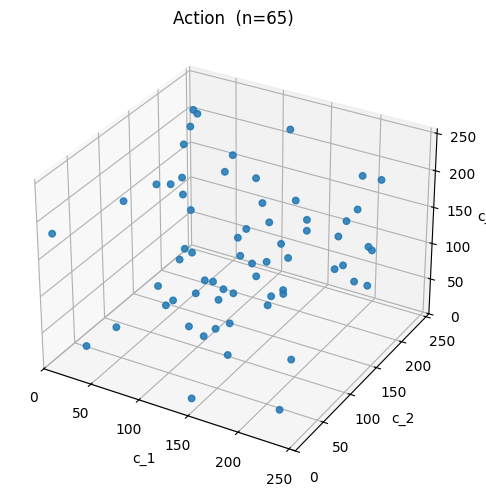

  Adventure      n=17


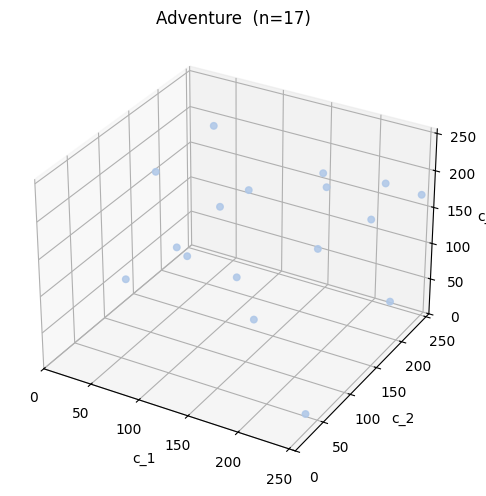

  Animation      n=2


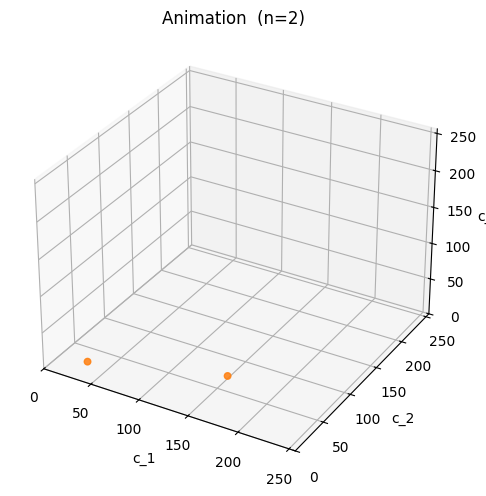

  Children's     n=5


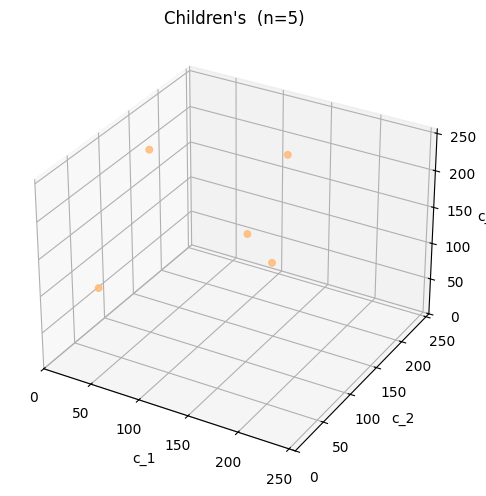

  Comedy         n=521


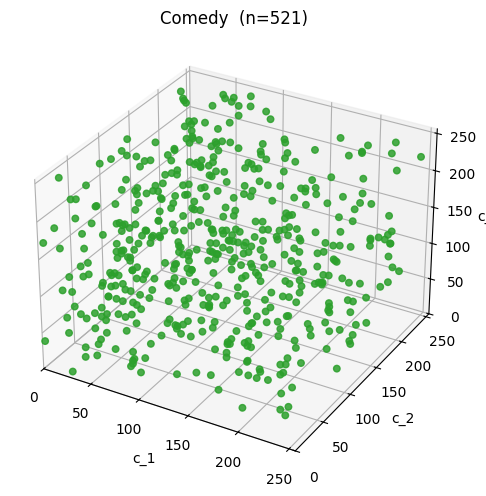

  Crime          n=26


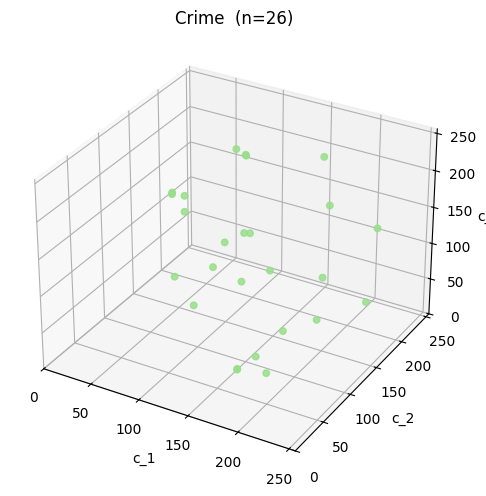

  Documentary    n=116


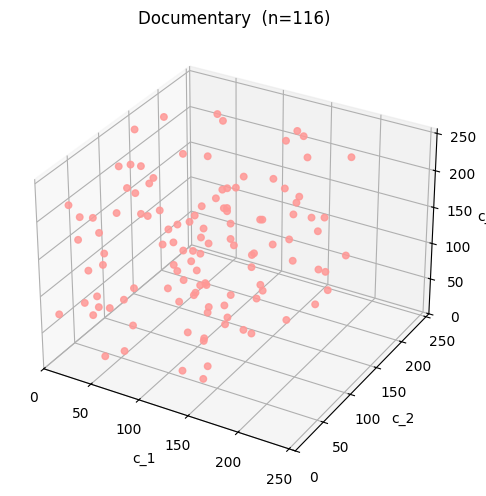

  Drama          n=843


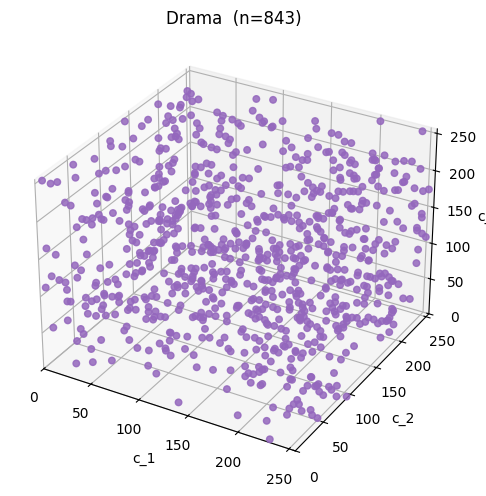

  Fantasy        n=1


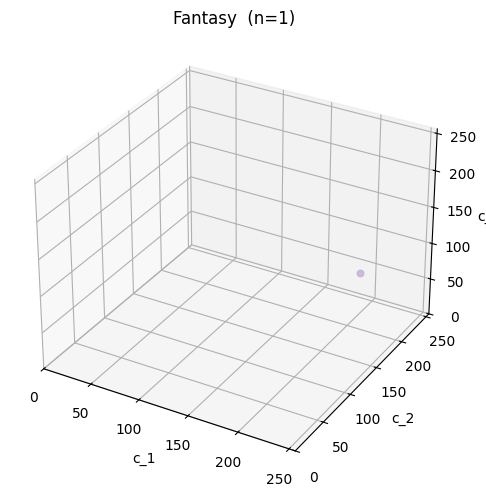

  Film-Noir      n=10


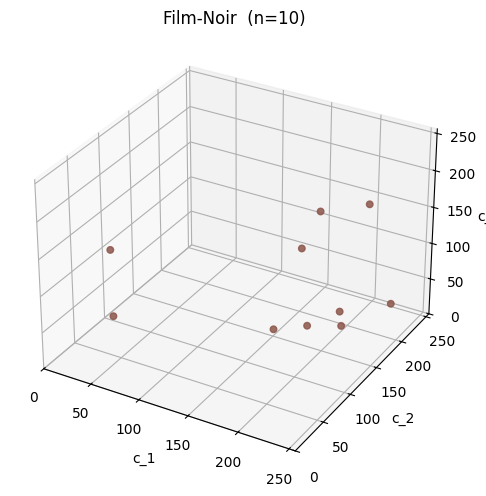

  Horror         n=178


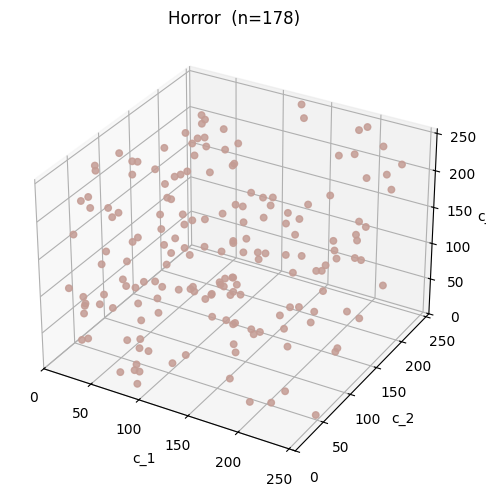

  Musical        n=18


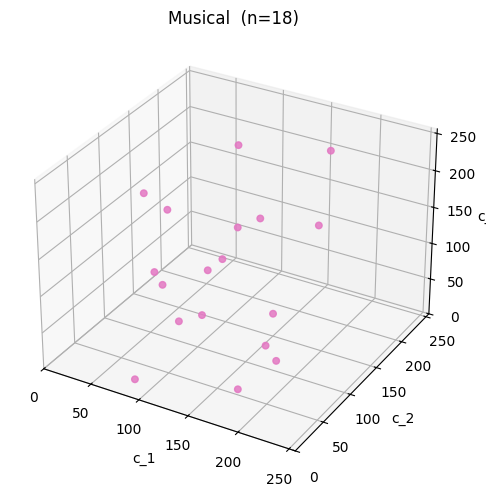

  Mystery        n=10


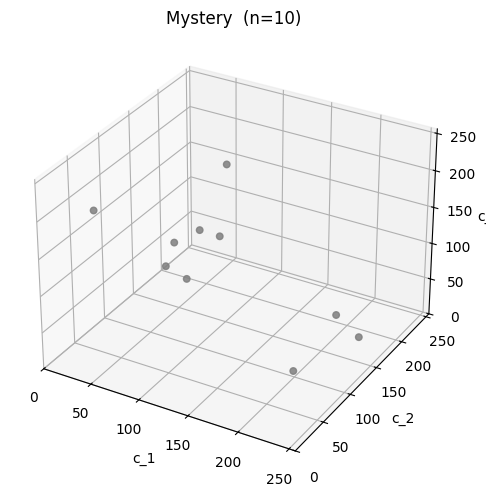

  Romance        n=40


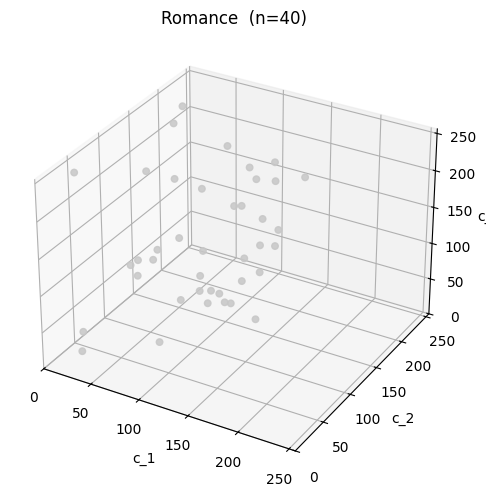

  Sci-Fi         n=27


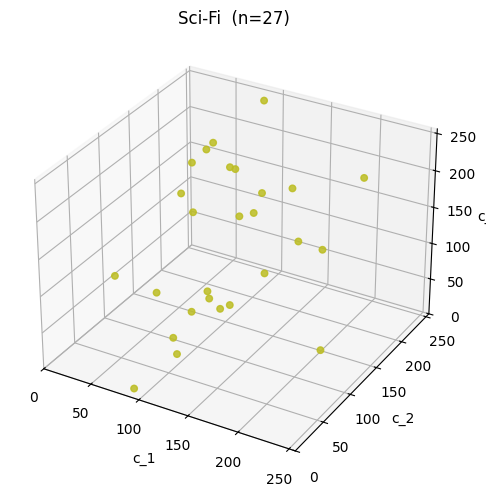

  Thriller       n=101


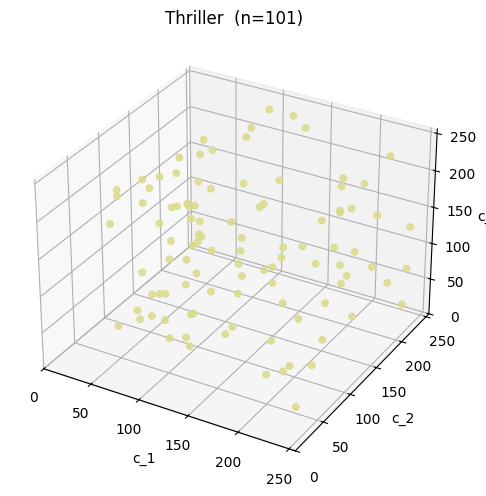

  War            n=12


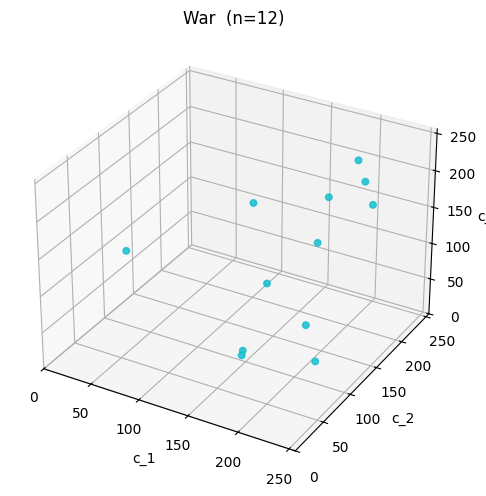

  Western        n=33


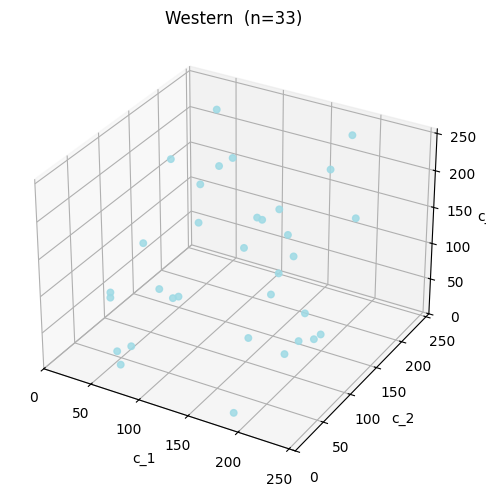

In [28]:
import pandas as pd
import torch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

from src.generate_sids import build_model_from_checkpoint, encode_all


def _load_l3_sids(checkpoint_path: str) -> tuple[np.ndarray, np.ndarray, int]:
    """Return (idx_s, genres, K) restricted to single-genre movies."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, _ = build_model_from_checkpoint(Path(checkpoint_path), device)
    assert model.quantizer.L == 3, f"L=3 only, got L={model.quantizer.L}"
    K = model.quantizer.K

    x = torch.from_numpy(np.load("outputs/embeddings.npy")).to(device)
    df = pd.read_csv("outputs/movies.csv").reset_index(drop=True)
    assert len(df) == x.shape[0], "movies/embeddings length mismatch"

    indices = encode_all(model, x).numpy()
    mask = ~df["genres"].str.contains(r"\|", regex=True, na=False)
    return indices[mask.values], df.loc[mask, "genres"].values, K


def plot_sids_3d(checkpoint_path: str, jitter: float = 0.25) -> None:
    """One independent 3D figure per genre. Avoids 3D subplot bleed where
    points from one panel visually leak into a neighbor's box."""
    idx_s, genres, K = _load_l3_sids(checkpoint_path)
    unique_genres = sorted(set(genres))
    cmap = plt.get_cmap("tab20", len(unique_genres))

    rng = np.random.default_rng(0)
    jitter_xyz = rng.uniform(-jitter, jitter, size=idx_s.shape)
    xyz = idx_s + jitter_xyz

    print(f"checkpoint: {checkpoint_path}  K={K}  single-genre movies: {len(idx_s)}")
    for i, g in enumerate(unique_genres):
        gm = genres == g
        n_g = int(gm.sum())
        # Sanity check: confirm the per-genre count matches what we're plotting.
        print(f"  {g:14s} n={n_g}")

        fig = plt.figure(figsize=(5.5, 5))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(
            xyz[gm, 0], xyz[gm, 1], xyz[gm, 2],
            s=22, alpha=0.85, color=cmap(i),
        )
        ax.set_xlim(0, K); ax.set_ylim(0, K); ax.set_zlim(0, K)
        ax.set_xlabel("c_1"); ax.set_ylabel("c_2"); ax.set_zlabel("c_3")
        ax.set_title(f"{g}  (n={n_g})")
        fig.tight_layout()
        plt.show()


plot_sids_3d("outputs/exp_L3_K256/checkpoints/best.pt")

In [34]:
def sid_stats_by_genre(checkpoint_path: str) -> pd.DataFrame:
    """Per-dimension descriptive stats of SIDs, grouped by single genre.

    Returns a DataFrame with a MultiIndex column (dim x stat) — rows are
    genres, columns are count/mean/std/min/25%/50%/75%/max per c_1/c_2/c_3.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, _ = build_model_from_checkpoint(Path(checkpoint_path), device)
    assert model.quantizer.L == 3, f"L=3 only, got L={model.quantizer.L}"

    x = torch.from_numpy(np.load("outputs/embeddings.npy")).to(device)
    df = pd.read_csv("outputs/movies.csv").reset_index(drop=True)
    indices = encode_all(model, x).numpy()

    mask = ~df["genres"].str.contains(r"\|", regex=True, na=False)
    sids = pd.DataFrame(indices[mask.values], columns=["c_1", "c_2", "c_3"])
    sids["genre"] = df.loc[mask, "genres"].values

    stats = (
        sids.groupby("genre")[["c_1", "c_2", "c_3"]]
        .describe()
        .round(2)
    )
    # Show the full table inline (scrollable in Jupyter) instead of pandas' default
    # truncated repr that hides middle columns with "...".
    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
        "display.max_colwidth", None,
        "display.expand_frame_repr", False,
    ):
        display(stats)





In [35]:
sid_stats_by_genre("outputs/exp_L3_K256/checkpoints/best.pt")

c_1                                                        c_2                                                        c_3                                                   
             count    mean    std    min     25%    50%     75%    max  count    mean    std    min     25%    50%     75%    max  count    mean    std   min     25%    50%     75%    max
genre                                                                                                                                                                                      
Action        65.0  124.66  71.00    4.0   63.00  141.0  186.00  254.0   65.0  137.23  69.79    7.0   80.00  140.0  196.00  251.0   65.0  118.63  73.96   0.0   55.00  124.0  181.00  252.0
Adventure     17.0  158.12  66.97    7.0  149.00  149.0  203.00  253.0   17.0  138.65  92.94    0.0   62.00  127.0  236.00  251.0   17.0  152.65  75.85  20.0   92.00  166.0  210.00  246.0
Animation      2.0  107.50  96.87   39.0   73.25  107.5  141.75  176.0    2.0   18.00   8.49   12.0   15.00   18.0   21.00   24.0    2.0   33.00  21.21  18.0   25.50   33.0   40.50   48.0
Children's     5.0  104.20  77.05   18.0   23.00  152.0  152.00  176.0    5.0  117.00  51.79   58.0   65.00  144.0  147.00  171.0    5.0  169.00  72.87  74.0  108.00  213.0  213.00  237.0
Comedy       521.0  110.53  71.13    1.0   55.00   81.0  168.00  249.0  521.0  122.92  76.76    0.0   58.00  116.0  194.00  255.0  521.0  124.60  75.68   0.0   59.00  114.0  195.00  254.0
Crime         26.0  152.46  40.97  106.0  106.00  177.0  177.00  208.0   26.0  109.77  68.89   18.0   51.00   87.0  177.00  244.0   26.0  140.54  83.88   3.0   62.25  144.5  219.25  245.0
Documentary  116.0   97.33  57.90    4.0   34.00  114.0  142.00  221.0  116.0  116.55  76.20    0.0   46.00  110.5  185.00  252.0  116.0  129.03  70.24   1.0   71.50  142.5  183.25  246.0
Drama        843.0  137.06  81.98    0.0   62.00  154.0  203.50  255.0  843.0  127.27  73.46    0.0   66.00  121.0  193.50  255.0  843.0  126.99  73.28   0.0   65.00  124.0  190.00  255.0
Fantasy        1.0  203.00    NaN  203.0  203.00  203.0  203.00  203.0    1.0  218.00    NaN  218.0  218.00  218.0  218.00  218.0    1.0   63.00    NaN  63.0   63.00   63.0   63.00   63.0
Film-Noir     10.0  193.70  74.48   46.0  229.00  229.0  229.00  229.0   10.0   96.20  70.94    9.0   47.75   78.5  131.00  230.0   10.0  129.50  74.41  22.0   65.75  125.0  186.50  242.0
Horror       178.0  106.22  71.52   14.0   30.00   87.0  170.00  253.0  178.0  129.55  76.26    1.0   58.25  139.0  199.25  255.0  178.0  115.00  78.03   2.0   43.25  103.0  184.25  255.0
Musical       18.0  128.72  54.74    9.0   94.50  102.0  190.00  196.0   18.0   96.61  57.04    7.0   53.50   94.5  152.50  180.0   18.0  119.61  81.44   2.0   42.75  118.0  172.00  250.0
Mystery       10.0  107.20  84.42   10.0   46.00   77.0  187.50  229.0   10.0  137.50  59.55   55.0   77.50  169.0  187.00  196.0   10.0   91.80  74.20  15.0   27.75   63.5  170.50  188.0
Romance       40.0   82.55  39.44    3.0   71.00   91.0   96.00  171.0   40.0  144.68  70.37    6.0  108.25  157.0  202.50  249.0   40.0  111.60  74.88   2.0   44.00  111.0  174.00  243.0
Sci-Fi        27.0  119.59  55.25   14.0   94.00   94.0  148.00  253.0   27.0  120.15  59.85    2.0   79.50  117.0  167.00  233.0   27.0  138.30  89.90   6.0   45.50  180.0  223.50  254.0
Thriller     101.0  127.32  70.98   14.0   69.00  116.0  210.00  253.0  101.0  136.12  69.83    8.0   82.00  136.0  202.00  253.0  101.0  123.90  74.90   0.0   61.00  120.0  195.00  246.0
War           12.0  182.75  51.69   57.0  181.00  181.0  215.00  254.0   12.0  123.17  57.64   39.0   75.25  133.5  172.00  199.0   12.0  138.17  79.21  21.0   70.75  141.0  211.75  243.0
Western       33.0  133.58  68.50   32.0   57.00  155.0  196.00  217.0   33.0  105.76  61.12    0.0   47.00  114.0  145.00  220.0   33.0  126.03  87.07   2.0   32.00  133.0  199.00  255.0

checkpoint: outputs/exp_L3_K128/checkpoints/best.pt  K=128  single-genre movies: 2025
  Action         n=65


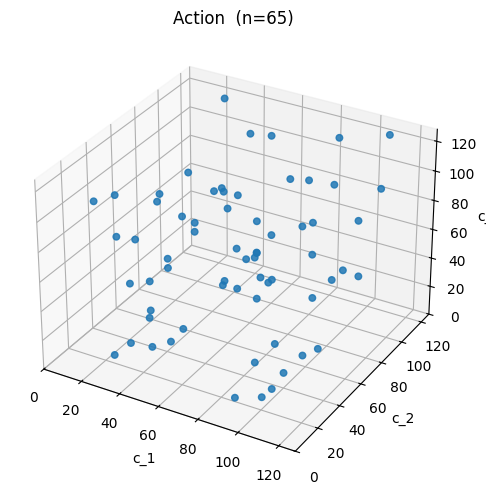

  Adventure      n=17


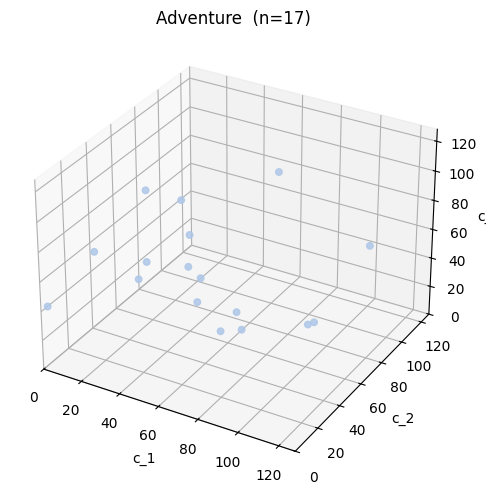

  Animation      n=2


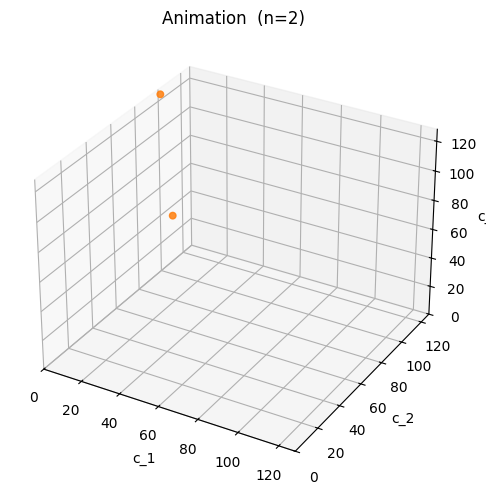

  Children's     n=5


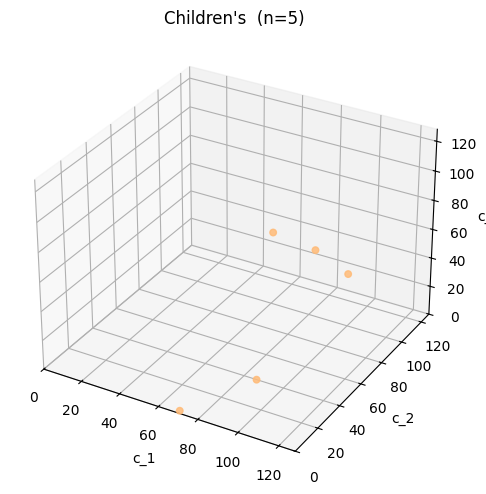

  Comedy         n=521


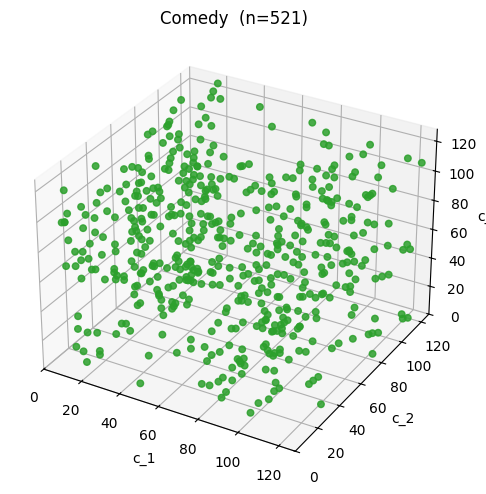

  Crime          n=26


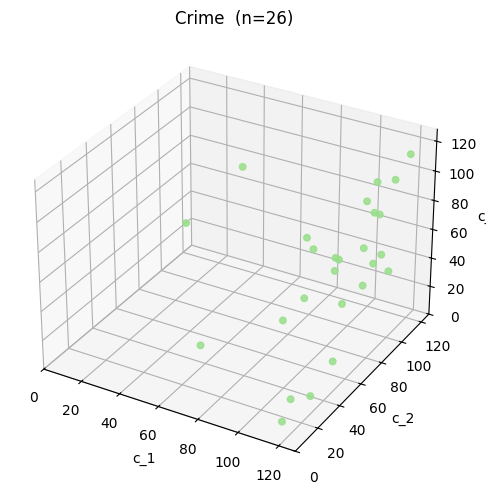

  Documentary    n=116


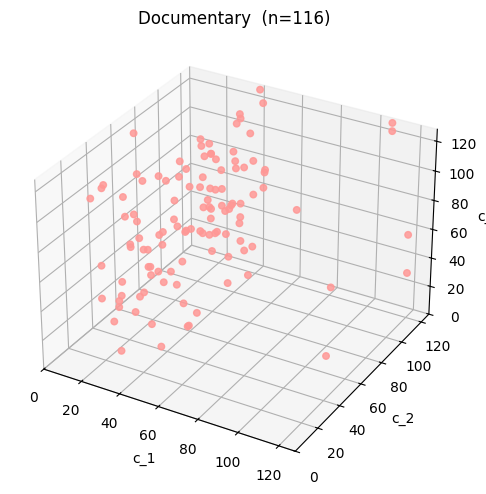

  Drama          n=843


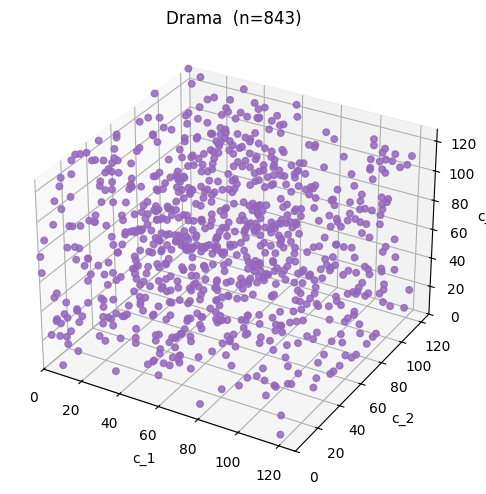

  Fantasy        n=1


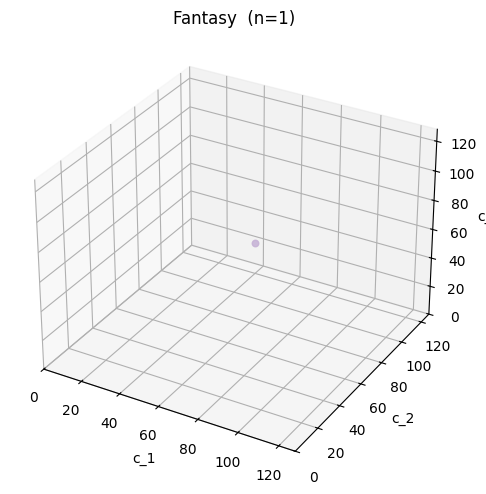

  Film-Noir      n=10


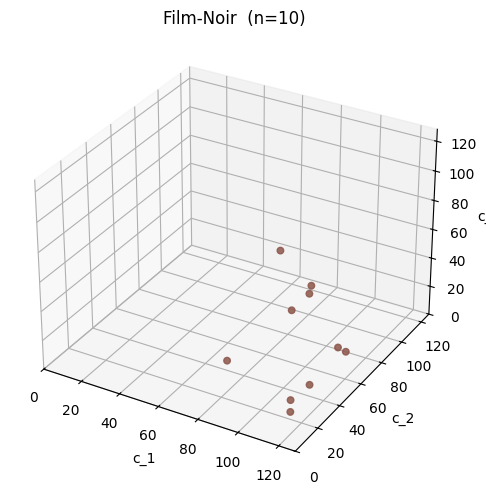

  Horror         n=178


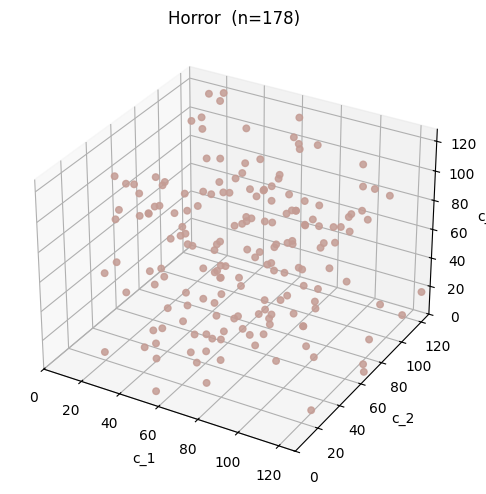

  Musical        n=18


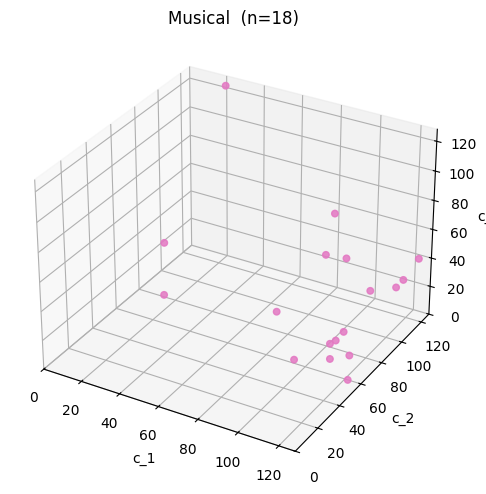

  Mystery        n=10


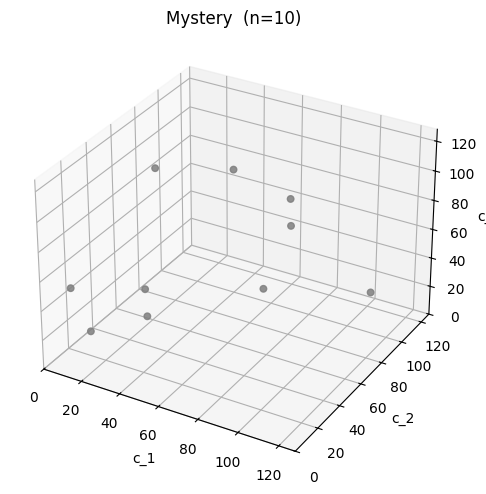

  Romance        n=40


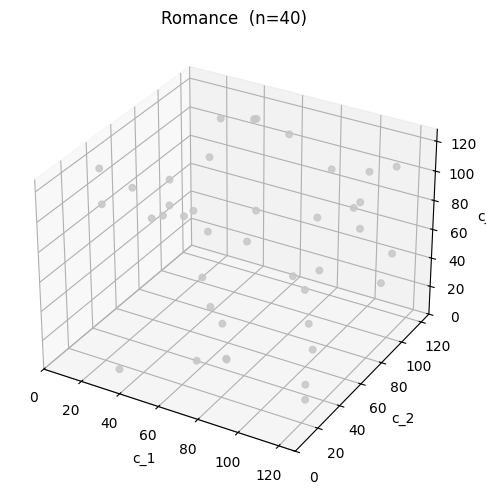

  Sci-Fi         n=27


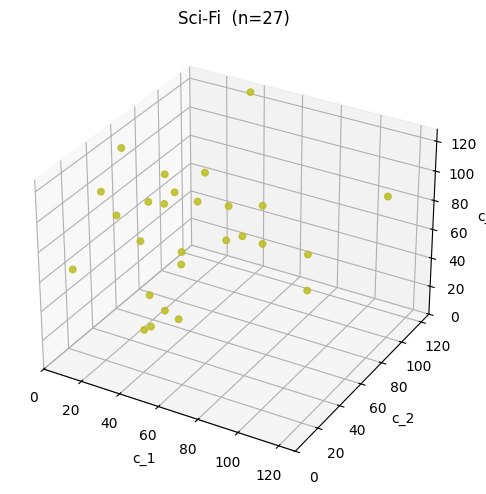

  Thriller       n=101


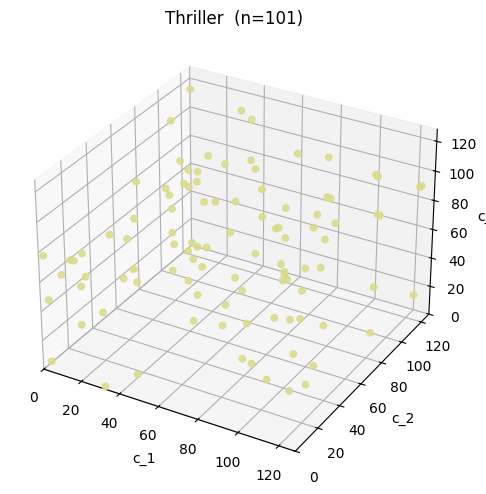

  War            n=12


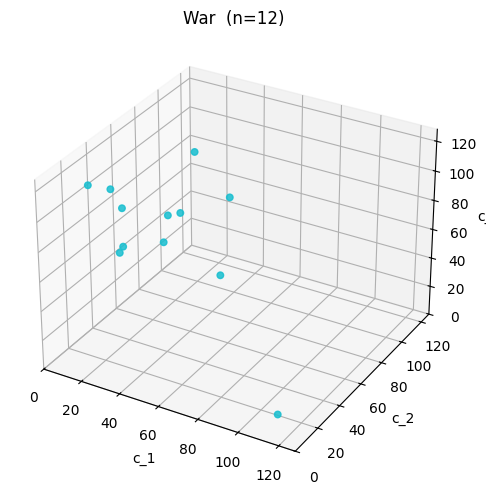

  Western        n=33


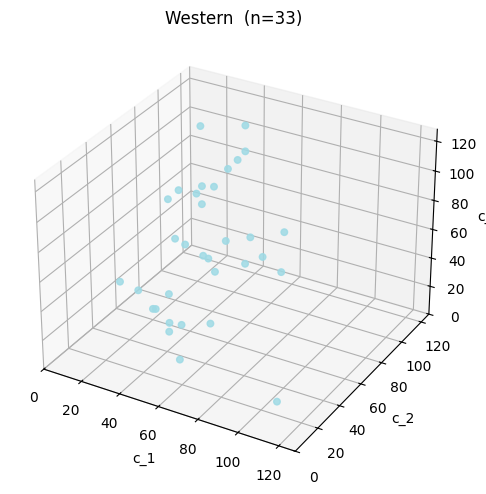

In [31]:
plot_sids_3d("outputs/exp_L3_K128/checkpoints/best.pt")

In [37]:
sid_stats_by_genre("outputs/exp_L3_K128/checkpoints/best.pt")

c_1                                                       c_2                                                    c_3                                                    
             count    mean    std   min     25%    50%     75%    max  count   mean    std   min    25%   50%     75%    max  count    mean    std    min     25%    50%     75%    max
genre                                                                                                                                                                                  
Action        65.0   67.25  31.09  19.0   34.00   63.0   92.00  119.0   65.0  56.95  37.20   1.0  25.00  48.0   85.00  124.0   65.0   65.97  38.19    4.0   27.00   69.0   97.00  125.0
Adventure     17.0   44.18  37.20   1.0    3.00   52.0   61.00  116.0   17.0  67.35  27.70   1.0  66.00  74.0   83.00  111.0   17.0   39.18  32.50    0.0   17.00   44.0   56.00  115.0
Animation      2.0   33.50  44.55   2.0   17.75   33.5   49.25   65.0    2.0  52.50  65.76   6.0  29.25  52.5   75.75   99.0    2.0  125.50   0.71  125.0  125.25  125.5  125.75  126.0
Children's     5.0   82.60  12.82  68.0   71.00   84.0   95.00   95.0    5.0  64.00  48.52   0.0  25.00  87.0   98.00  110.0    5.0   31.20  24.45    2.0   15.00   28.0   49.00   62.0
Comedy       521.0   59.29  38.42   8.0   22.00   45.0   87.00  127.0  521.0  63.98  35.71   0.0  30.00  65.0   96.00  127.0  521.0   61.82  35.94    0.0   33.00   62.0   92.00  127.0
Crime         26.0  112.69  19.98  54.0  119.00  120.0  120.00  121.0   26.0  57.85  32.55   1.0  35.00  53.5   84.75  119.0   26.0   74.58  35.63    6.0   54.25   83.5  103.75  125.0
Documentary  116.0   39.96  20.38  12.0   27.00   38.0   41.00  120.0  116.0  69.89  37.42   0.0  38.75  70.0  102.00  127.0  116.0   71.06  34.01    0.0   51.00   69.5   97.75  127.0
Drama        843.0   56.51  35.80   0.0   31.00   55.0   85.00  126.0  843.0  64.16  36.43   0.0  35.00  64.0   96.00  127.0  843.0   66.82  38.35    0.0   33.50   66.0  101.00  127.0
Fantasy        1.0   61.00    NaN  61.0   61.00   61.0   61.00   61.0    1.0  83.00    NaN  83.0  83.00  83.0   83.00   83.0    1.0   55.00    NaN   55.0   55.00   55.0   55.00   55.0
Film-Noir     10.0  108.40  14.55  67.0  113.00  113.0  113.00  113.0   10.0  38.60  19.77  12.0  23.00  39.0   45.25   74.0   10.0   37.50  41.85    0.0    6.50   12.5   71.00  117.0
Horror       178.0   66.76  29.17  20.0   36.75   66.0   80.00  125.0  178.0  64.33  34.53   0.0  36.00  66.0   90.00  127.0  178.0   64.59  37.20    0.0   32.25   64.0   95.00  127.0
Musical       18.0  102.94  40.81   9.0  123.00  123.0  123.00  123.0   18.0  66.22  32.38   7.0  42.00  57.5   86.00  125.0   18.0   49.50  36.84    3.0   30.25   39.5   53.00  127.0
Mystery       10.0   50.10  35.18   1.0   31.50   53.0   60.50  113.0   10.0  58.30  38.71   2.0  25.75  58.0   89.50  116.0   10.0   57.10  41.04    0.0   33.00   52.5   86.25  114.0
Romance       40.0   71.97  31.82  13.0   39.00   74.5  109.00  113.0   40.0  62.40  36.52   1.0  31.00  51.0   92.00  127.0   40.0   73.28  41.93    1.0   27.00   93.5  108.50  127.0
Sci-Fi        27.0   43.22  34.65   5.0   36.00   36.0   36.00  126.0   27.0  58.37  30.18  12.0  38.00  47.0   77.50  122.0   27.0   71.63  37.51    0.0   39.50   80.0   97.50  126.0
Thriller     101.0   61.66  41.73   1.0   30.00   53.0  106.00  122.0  101.0  58.57  40.63   0.0  26.00  47.0   98.00  127.0  101.0   67.16  38.87    0.0   31.00   66.0  101.00  127.0
War           12.0   38.17  33.69  12.0   12.00   27.5   44.50  117.0   12.0  44.00  37.44   4.0  19.00  38.0   57.00  112.0   12.0   79.75  27.59   17.0   69.75   84.5   98.00  115.0
Western       33.0   49.48  13.72  28.0   52.00   52.0   52.00  107.0   33.0  58.97  32.58  12.0  31.00  52.0   90.00  127.0   33.0   62.27  40.17    3.0   30.00   57.0  108.00  127.0

checkpoint: outputs/exp_L3_K64/checkpoints/best.pt  K=64  single-genre movies: 2025
  Action         n=65


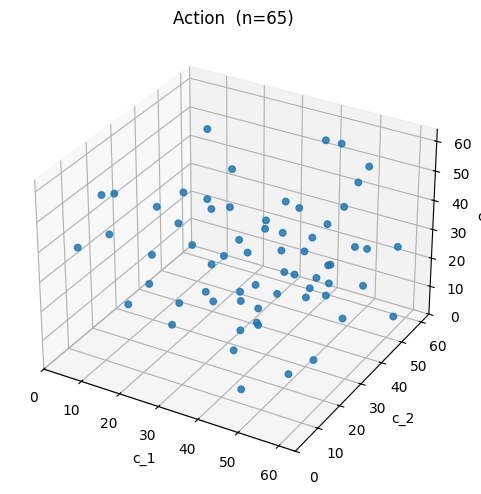

  Adventure      n=17


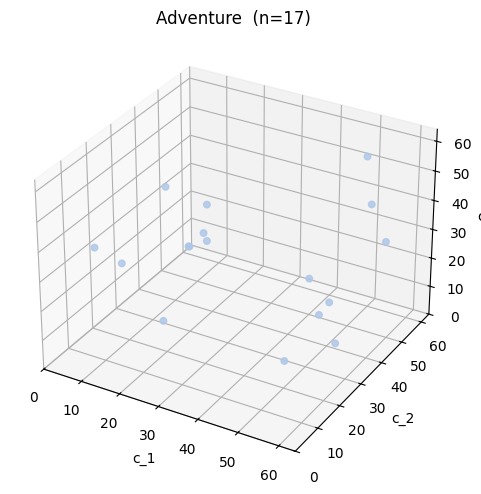

  Animation      n=2


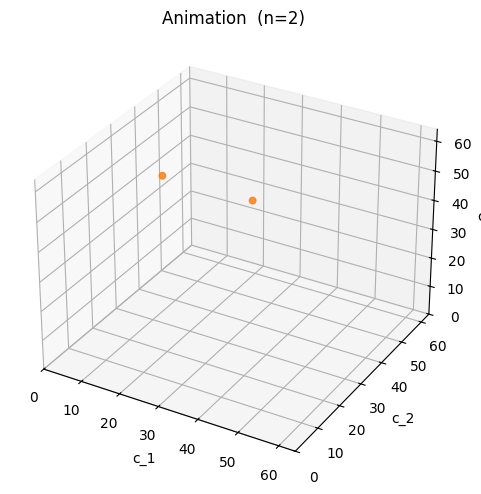

  Children's     n=5


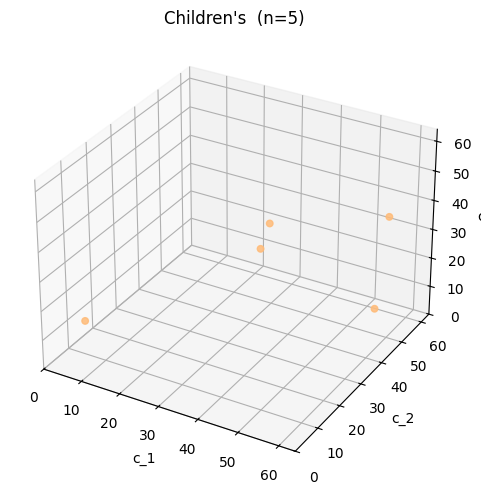

  Comedy         n=521


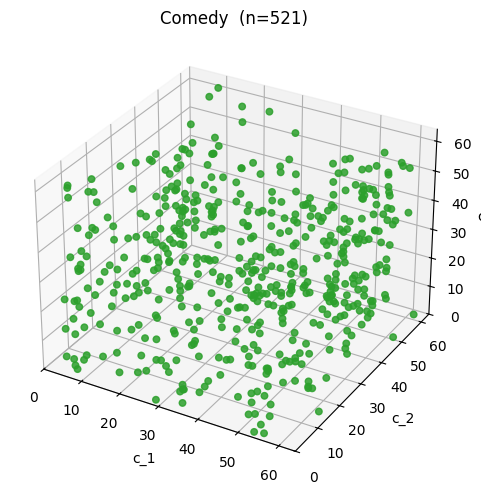

  Crime          n=26


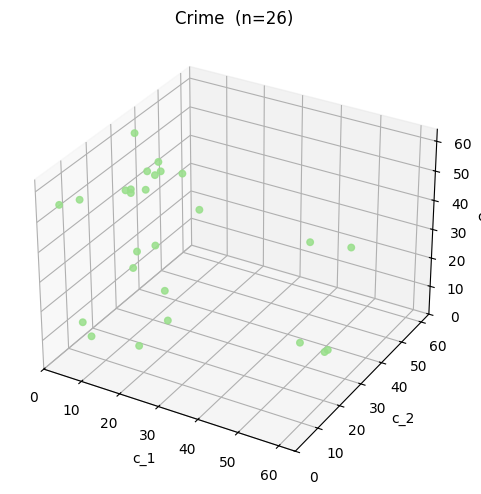

  Documentary    n=116


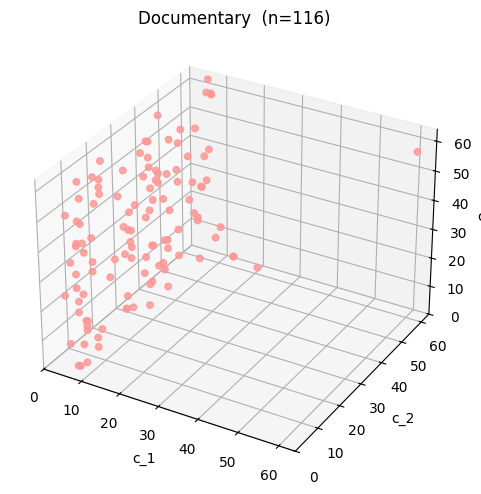

  Drama          n=843


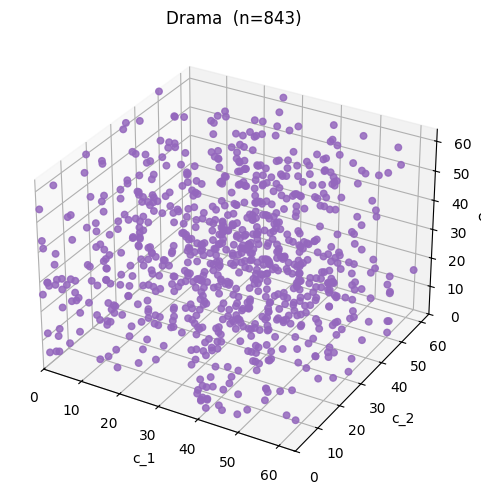

  Fantasy        n=1


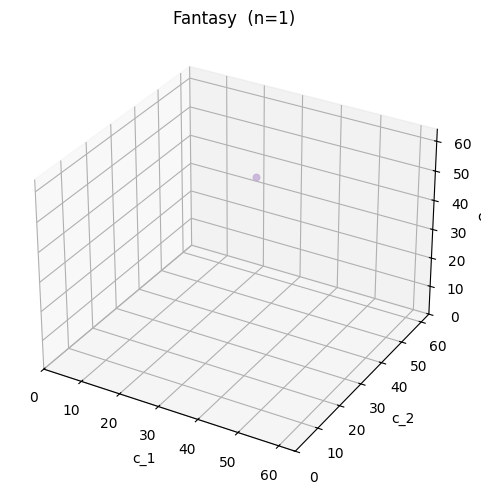

  Film-Noir      n=10


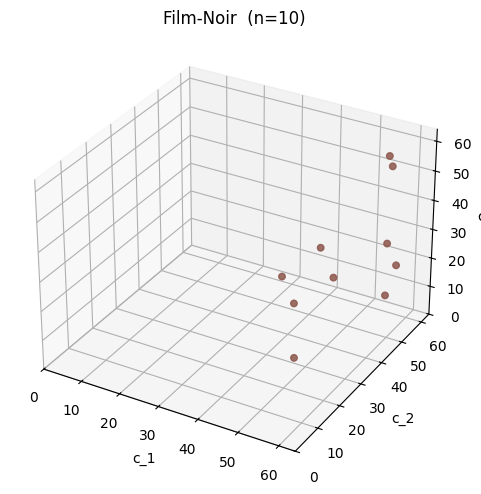

  Horror         n=178


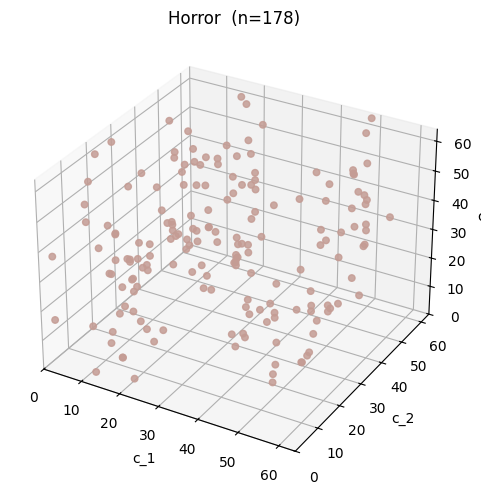

  Musical        n=18


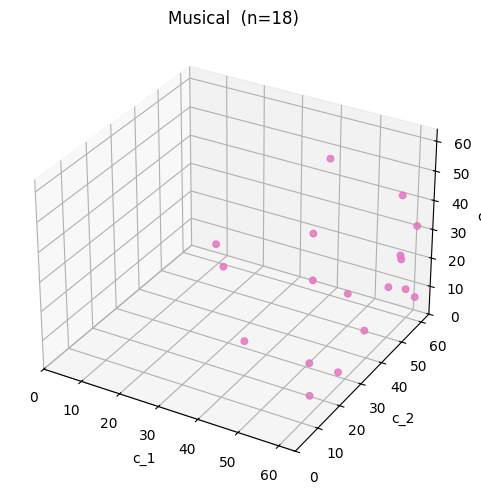

  Mystery        n=10


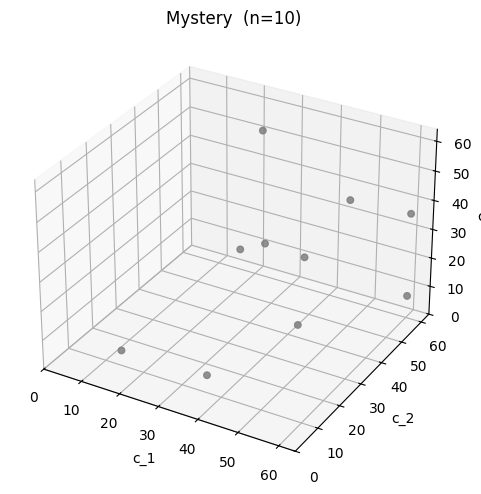

  Romance        n=40


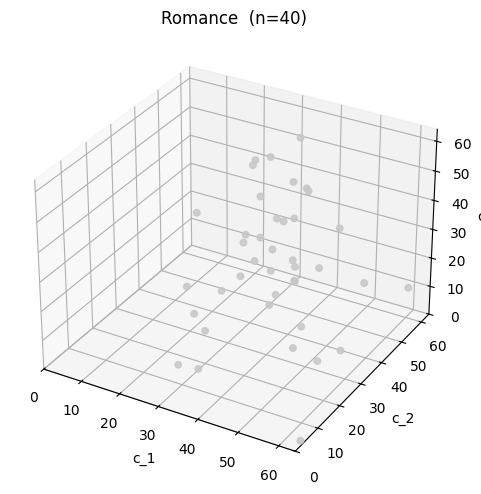

  Sci-Fi         n=27


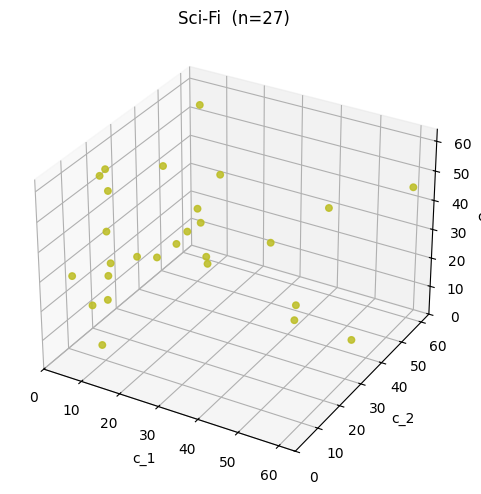

  Thriller       n=101


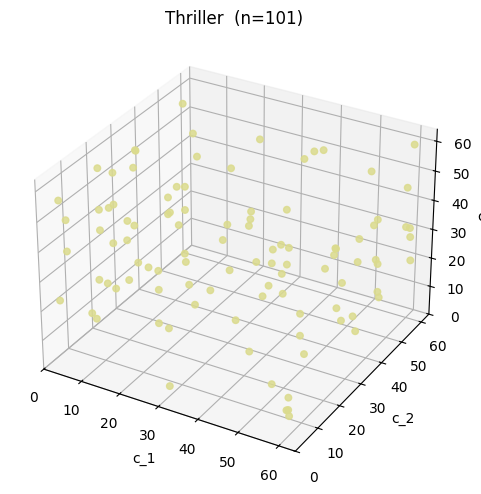

  War            n=12


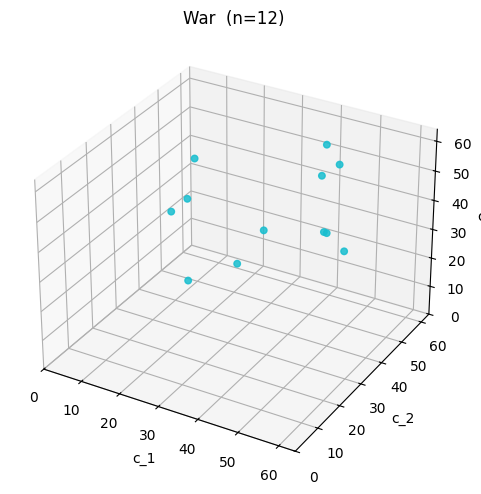

  Western        n=33


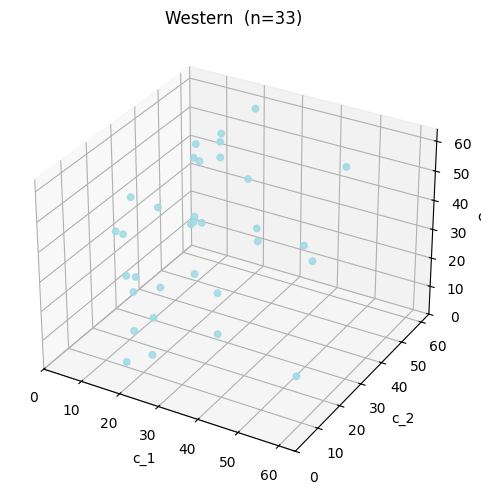

In [38]:
plot_sids_3d("outputs/exp_L3_K64/checkpoints/best.pt")